# **Project Overview**

In this project, we’re going to build a toxic comment classifier. The idea is to automatically detect comments that are offensive, abusive, or inappropriate—similar to how social platforms flag harmful content. Our model will try to recognize different kinds of toxicity and classify them accordingly.

Variables:
- id - unique number for each sample
- comment_text - comments that are classified
- toxic - ```0``` or ```1```, shows whether the comment is toxic
- severe_toxic - ```0``` or ```1```, whether the toxicity is considered severe
- obscene - ```0``` or ```1```, whether the comment contains obscene language
- threat - ```0``` or ```1```, indicates if the comment contains threats
- insult - ```0``` or ```1```, flags insulting language
- identity_hate - ```0``` or ```1```, whether the comment targets a specific identity group

# 1. **Install and import dependencies**

We will approach this project using three different methods:
1. PyTorch + BERT
2. Logistic Regression / SVC
3. TensorFlow BiLSTM

Because we'll be implementing multiple approaches, we'll need to install several libraries. Some commonly required packages include:
- pandas
- matplotlib
- seaborn
- scikit-learn
- wordcloud

In [2]:
!pip install tensorflow[and-cuda] pandas matplotlib seaborn scikit-learn wordcloud


[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: pip install --upgrade pip


For PyTorch + BERT we also need to install two additional libraries:
- torch
- transformers

In [3]:
!pip install torch transformers


[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: pip install --upgrade pip


So first step — import all the libraries required for our project.

In [4]:
# Import necessary libraries

# Import data manipulation libraries
import pandas as pd
import numpy as np

# Import visualization libraries
import matplotlib.pyplot as plt 
import seaborn as sns
from wordcloud import WordCloud

# Import machine learning libraries

# Import scikit-learn for data splitting and evaluation
from sklearn.model_selection import train_test_split

# Import PyTorch and Transformers for model building method 1
from transformers import AutoTokenizer, BertForSequenceClassification
import torch
from torch.utils.data import Dataset, DataLoader
from torch.optim import AdamW


# Import scikit-learn components for text processing and classification method 2
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.pipeline import Pipeline
from sklearn.svm import LinearSVC
from sklearn.multiclass import OneVsRestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import MultinomialNB
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import roc_auc_score, accuracy_score, roc_curve, classification_report
from sklearn.metrics import f1_score, precision_score, recall_score

2026-04-20 17:22:39.555449: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2026-04-20 17:22:40.389010: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX512F AVX512_VNNI FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
2026-04-20 17:22:42.807087: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.


# 2. **Exploratory Data Analysis (EDA)**

#### **Inspecting the data**

Now let’s load our dataset.

In [5]:
# Load the dataset
df = pd.read_csv('train.csv')

Let's take a look on our dataset.

In [6]:
# Display the first few rows of the dataset
df.head()

,id,comment_text,toxic,severe_toxic,obscene,threat,insult,identity_hate
0,0000997932d777bf,Explanation\nWhy the edits made under my usern...,0,0,0,0,0,0
1,000103f0d9cfb60f,D'aww! He matches this background colour I'm s...,0,0,0,0,0,0
2,000113f07ec002fd,"Hey man, I'm really not trying to edit war. It...",0,0,0,0,0,0
3,0001b41b1c6bb37e,"""\nMore\nI can't make any real suggestions on ...",0,0,0,0,0,0
4,0001d958c54c6e35,"You, sir, are my hero. Any chance you remember...",0,0,0,0,0,0


Let's check the shape of the dataset.

In [7]:
# Display the shape of the dataset
df.shape

(159571, 8)

Dataset has 159571 rows and 8 columns. 

Now let's check more detailed information about the dataset.

In [8]:
# Display information about the dataset
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 159571 entries, 0 to 159570
Data columns (total 8 columns):
 #   Column         Non-Null Count   Dtype 
---  ------         --------------   ----- 
 0   id             159571 non-null  object
 1   comment_text   159571 non-null  object
 2   toxic          159571 non-null  int64 
 3   severe_toxic   159571 non-null  int64 
 4   obscene        159571 non-null  int64 
 5   threat         159571 non-null  int64 
 6   insult         159571 non-null  int64 
 7   identity_hate  159571 non-null  int64 
dtypes: int64(6), object(2)
memory usage: 9.7+ MB


In [9]:
# Display statistical summary of the dataset
df.describe()

,toxic,severe_toxic,obscene,threat,insult,identity_hate
count,159571.000000,159571.000000,159571.000000,159571.000000,159571.000000,159571.000000
mean,0.095844,0.009996,0.052948,0.002996,0.049364,0.008805
std,0.294379,0.099477,0.223931,0.054650,0.216627,0.093420
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
50%,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
75%,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
max,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000


Now let's check for missing values.

In [10]:
# Check for missing values
df.isnull().sum()

id               0
comment_text     0
toxic            0
severe_toxic     0
obscene          0
threat           0
insult           0
identity_hate    0
dtype: int64

Our dataset doesn't have any missing values. 


In [11]:
# Check for duplicate entries
df.duplicated().sum()

np.int64(0)

No duplicate entries found.

#### **Data Summary**

* **Shape**: 159571 rows, 8 columns
* **Data Types**:

  * `id`: `object`
  * `comment_text`: `object`
  * `toxic`: `int64`
  * `toxic`: `int64`
  * `severe_toxic`: `int64`
  * `obscene`: `int64`
  * `threat`: `int64`
  * `insult`: `int64`
* **Missing Values**: no found
* **Duplicate Values**: no found
* **Descriptive Statistics**:
  * `toxic`: `0` or `1`
  * `toxic`: `0` or `1`
  * `severe_toxic`: `0` or `1`
  * `obscene`: `0` or `1`
  * `threat`: `0` or `1`
  * `insult`: `0` or `1`

#### **Data Visualization**

Now let's check data distribution.

In [12]:
# Count of each toxicity label
df.iloc[:, 2:].sum() 

toxic            15294
severe_toxic      1595
obscene           8449
threat             478
insult            7877
identity_hate     1405
dtype: int64

We can see that dataset is highly imbalanced. Total amount of rows 159571, but only 15294 are toxic. 

Let's start with visualization.

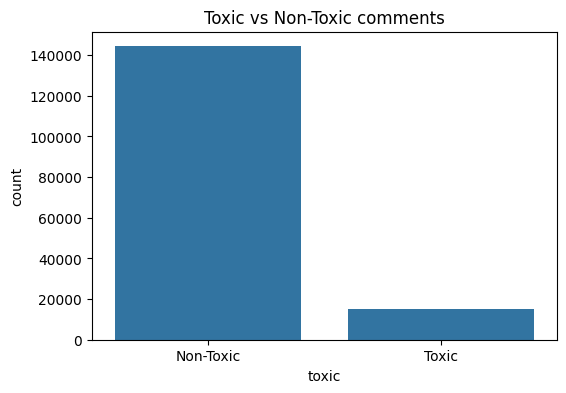

Counts:
toxic
0    144277
1     15294
Name: count, dtype: int64


In [13]:
# Visualize the distribution of toxic vs non-toxic comments
plt.figure(figsize=(6,4))
sns.countplot(x='toxic', data=df)
plt.xticks([0,1], ['Non-Toxic', 'Toxic'])
plt.title("Toxic vs Non-Toxic comments")
plt.show()

print("Counts:")
print(df['toxic'].value_counts())

Once again we can see that the dataset is imbalanced with a significantly higher number of non-toxic comments compared to toxic ones.

Let's check distribution of each label.

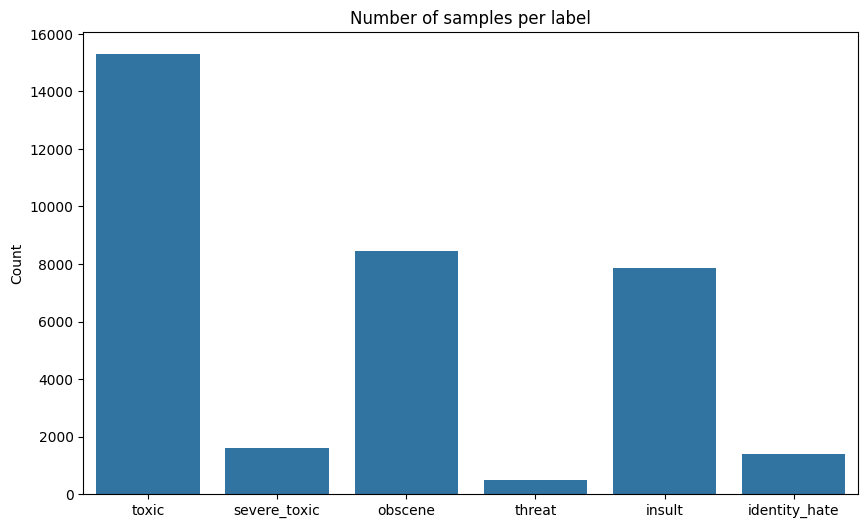

In [14]:
# Visualize the distribution of samples per toxicity label
label_cols = ['toxic','severe_toxic','obscene','threat','insult','identity_hate']

plt.figure(figsize=(10,6))
sns.barplot(x=label_cols, y=df[label_cols].sum().values)
plt.title("Number of samples per label")
plt.ylabel("Count")
plt.show()

The most common labels are `obscene` and `insult`, while `threat` and `identity_hate` are the least common.

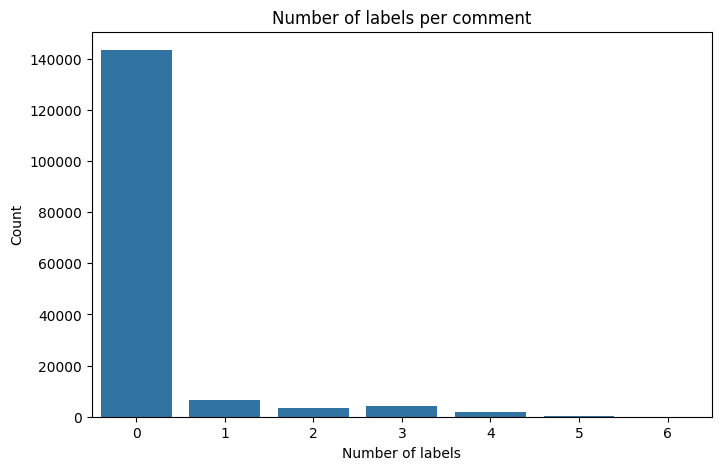

In [15]:
# Count how many labels each comment has
df['num_labels'] = df[label_cols].sum(axis=1)
plt.figure(figsize=(8,5))
sns.countplot(x='num_labels', data=df)
plt.title("Number of labels per comment")
plt.xlabel("Number of labels")
plt.ylabel("Count")
plt.show()


Usually toxic comments have either only one label or 3, rarely more than that.

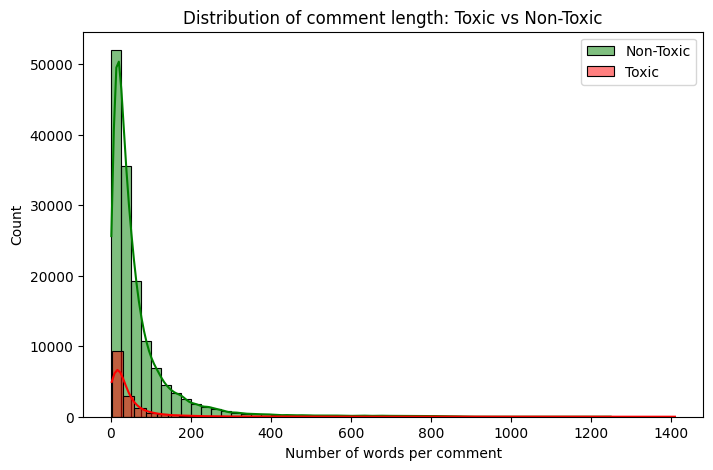

In [16]:
# Visualize the distribution of comment length for toxic vs non-toxic comments
df['comment_len'] = df['comment_text'].str.split().apply(len)

plt.figure(figsize=(8,5))
sns.histplot(df[df['toxic']==0]['comment_len'], color='green', label='Non-Toxic', kde=True, bins=50)
sns.histplot(df[df['toxic']==1]['comment_len'], color='red', label='Toxic', kde=True, bins=50)
plt.legend()
plt.xlabel("Number of words per comment")
plt.title("Distribution of comment length: Toxic vs Non-Toxic")
plt.show()

Comments usually have length between 0 and 200 words, with toxic comments tending to be slightly shorter on average.

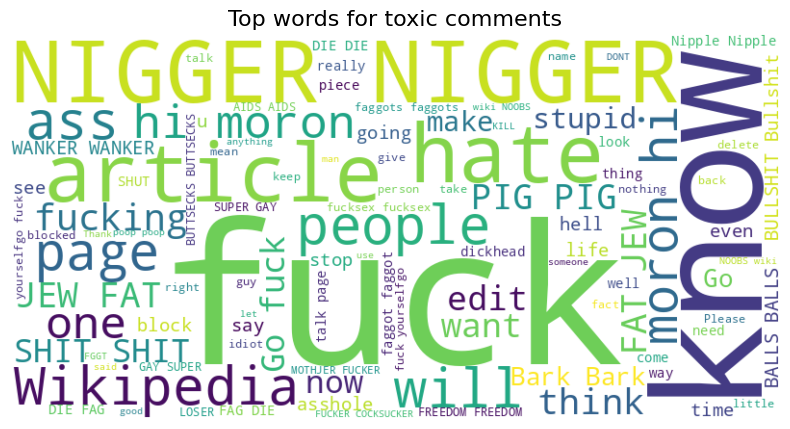

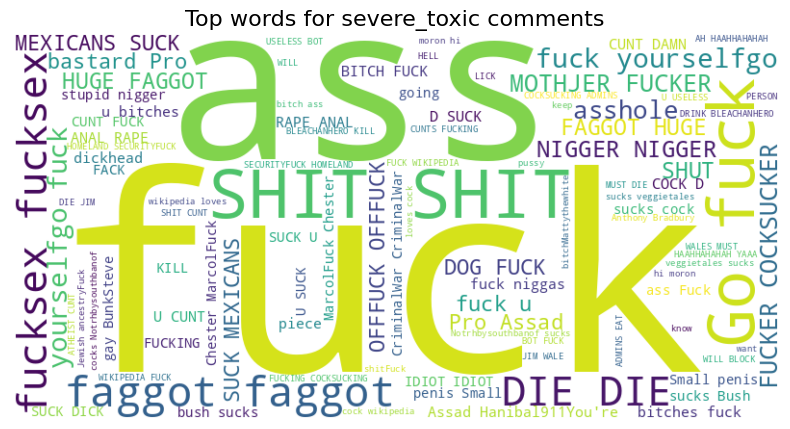

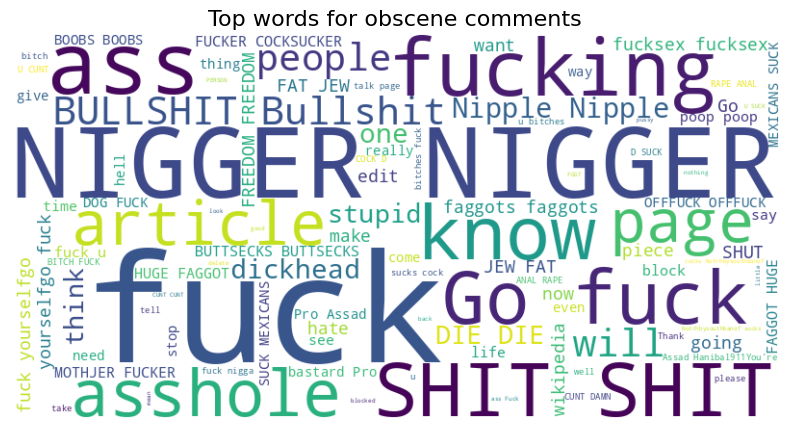

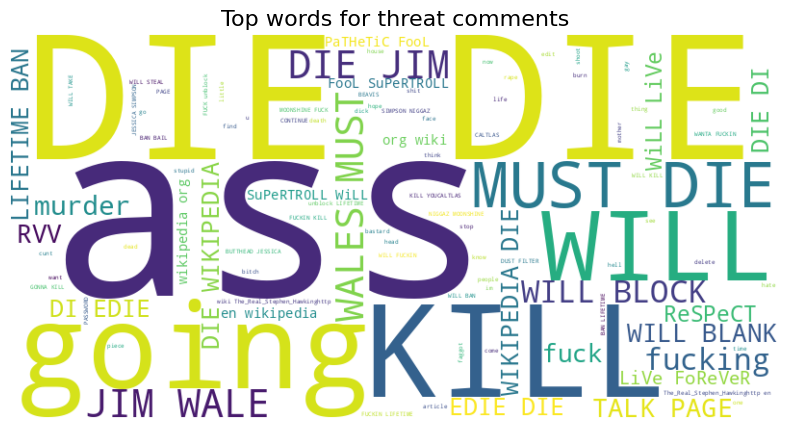

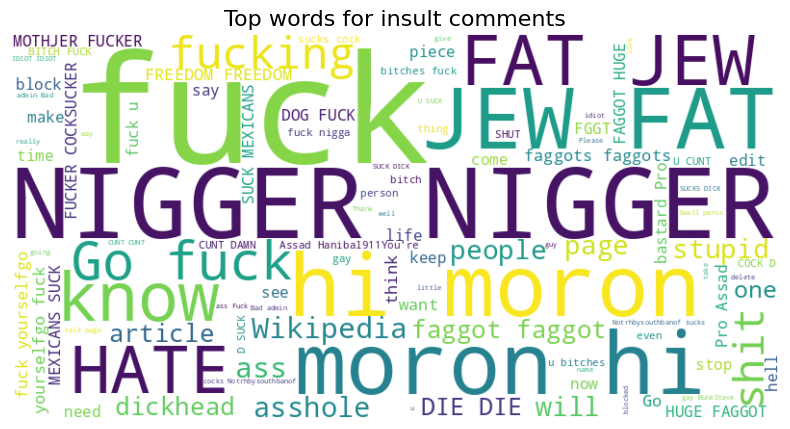

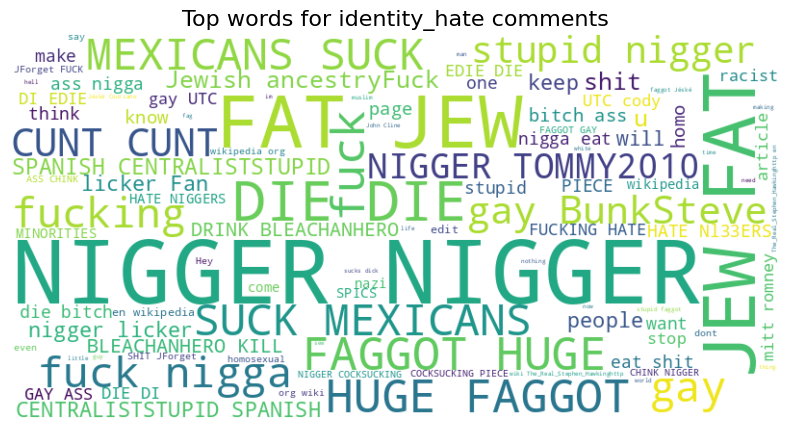

In [17]:
# Generate word clouds for each toxicity label
def plot_wordcloud(texts, title):
    wc = WordCloud(width=800, height=400, background_color='white', max_words=100).generate(" ".join(texts))
    plt.figure(figsize=(10,5))
    plt.imshow(wc, interpolation='bilinear')
    plt.axis('off')
    plt.title(title, fontsize=16)
    plt.show()

for label in label_cols:
    texts = df[df[label]==1]['comment_text'].tolist()
    if len(texts) > 0:
        plot_wordcloud(texts, f"Top words for {label} comments")

# 3. **PyTorch + BERT model**

#### **Model Training**

In [18]:
# Prepare data for modeling

# Convert Pandas DataFrame to list
text = df["comment_text"].tolist()

# Convert labels to numpy array
labels = df.drop(columns=['comment_text', 'id', 'num_labels', 'comment_len']).values


Now let's split the data into training, validation and testing sets.

In [19]:
# Split the data into training and temporary sets
train_texts, temp_texts, train_labels, temp_labels = train_test_split(
    text, labels, test_size=0.3, random_state=42
)

In [20]:
# Split the temporary set into validation and test sets
val_texts, test_texts, val_labels, test_labels = train_test_split(
    temp_texts, temp_labels, test_size=0.3, random_state=42
)

* Training set: 70%
* Validation set: 20%
* Test set: 10%

Let's check length of every set.

In [21]:
# Print the sizes of each set
print("Train size:", len(train_texts))
print("Validation size:", len(val_texts))
print("Test size:", len(test_texts))

Train size: 111699
Validation size: 33510
Test size: 14362


First step of training the model is tokenization. 

**Tokenization** - splitting text into smaller units (tokens) and converting them into numbers, because models like BERT cannot read raw text. 

Here we will use `AutoTokenizer`. `AutoTokenizer` is a class from the Hugging Face library that automatically loads the correct tokenizer for a given pre-trained model. Model is `bert-base-uncased`.

In [22]:
# Initialize the tokenizer
tokenizer = AutoTokenizer.from_pretrained("google-bert/bert-base-uncased")

Let's create custom dataset class, for processing text data for BERT model.

In [23]:
# Create a custom Dataset class
class ToxicDataset(Dataset):
    def __init__(self, texts, labels, tokenizer, max_len=128):

        """
        Args:
            texts: list of comment strings
            labels: numpy array or list of multi-label targets
            tokenizer: Hugging Face tokenizer (e.g., AutoTokenizer)
            max_len: maximum token length for BERT
        """

        self.texts = texts
        self.labels = labels
        self.tokenizer = tokenizer
        self.max_len = max_len
    
    def __len__(self):
        # Return the number of samples in the dataset
        return len(self.texts)

    def __getitem__(self, idx):

        """
        Returns one sample at index `idx` as a dictionary containing:
        - input_ids: token IDs for BERT
        - attention_mask: mask to ignore padded tokens
        - labels: multi-label tensor for classification
        """

        enc = self.tokenizer(
            self.texts[idx],              # get the text for this sample
            max_length=self.max_len,      # pad/truncate to max_len
            truncation=True,              # truncate if text is too long
            padding="max_length",         # pad short texts
            return_tensors="pt"           # return PyTorch tensors
        )

        return {
            "input_ids": enc["input_ids"].squeeze(),
            "attention_mask": enc["attention_mask"].squeeze(),
            "labels": torch.tensor(self.labels[idx], dtype=torch.float)
        }
    
    

Let's prepare the datasets and dataloaders for training and validation.

In [24]:
# Wrap training and validation data into custom Dataset objects
train_dataset = ToxicDataset(train_texts, train_labels, tokenizer)  # Dataset for training
val_dataset = ToxicDataset(val_texts, val_labels, tokenizer)        # Dataset for validation

# Define batch size for training
BATCH_SIZE = 8  # small batch size can help avoid GPU memory issues

# Create DataLoaders for batching, shuffling, and efficient data loading
train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,  # number of samples per batch
    shuffle=True            # shuffle the dataset at every epoch for better training
)

val_loader = DataLoader(
    val_dataset,
    batch_size=BATCH_SIZE   # no shuffling for validation
)

In [25]:
# Count how many positive samples exist for each label (sum along rows)
label_sums = train_labels.sum(axis=0)  

# Total number of samples in the dataset
total = len(train_labels)  

# Compute positive weights for each label
# Formula: pos_weight = (num_negative / num_positive)
# Used to give more importance to rare classes during training
pos_weight = (total - label_sums) / (label_sums + 1e-6)  # add small epsilon to avoid division by zero

# Convert to PyTorch tensor and move to GPU
pos_weight = torch.tensor(pos_weight).float().cuda()
# Print positive weights for each label
print("Positive weights for each label:", pos_weight)

Positive weights for each label: tensor([  9.4275,  99.7205,  17.9545, 325.6053,  19.3533, 113.7986],
       device='cuda:0')


We have now weights for our labels. This helps us to deal with imbalance. Higher weight - rare label. 

Now we will initialize the BERT model for multi-label classification.

In [26]:
# Initialise the device (GPU if available, else CPU)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# Initialize the BERT model for multi-label classification
model = BertForSequenceClassification.from_pretrained(
    "bert-base-uncased",
    num_labels=6,
    problem_type="multi_label_classification"
)

Some weights of BertForSequenceClassification were not initialized from the model checkpoint at bert-base-uncased and are newly initialized: ['classifier.bias', 'classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


Next we define loss function. 

BCEWithLogitsLoss is a loss function for multi-label classification.

Works for each label independently, so it’s perfect for multi-label toxic comment classification.
    
`pos_weight` is a tensor of positive class weights we computed earlier.

Purpose: give more importance to rare labels so the model doesn’t ignore them.

In [27]:
# Define the loss function with positive weights to handle class imbalance
loss_fn = torch.nn.BCEWithLogitsLoss(pos_weight=pos_weight)
model.to(device)

BertForSequenceClassification(
  (bert): BertModel(
    (embeddings): BertEmbeddings(
      (word_embeddings): Embedding(30522, 768, padding_idx=0)
      (position_embeddings): Embedding(512, 768)
      (token_type_embeddings): Embedding(2, 768)
      (LayerNorm): LayerNorm((768,), eps=1e-12, elementwise_affine=True)
      (dropout): Dropout(p=0.1, inplace=False)
    )
    (encoder): BertEncoder(
      (layer): ModuleList(
        (0-11): 12 x BertLayer(
          (attention): BertAttention(
            (self): BertSdpaSelfAttention(
              (query): Linear(in_features=768, out_features=768, bias=True)
              (key): Linear(in_features=768, out_features=768, bias=True)
              (value): Linear(in_features=768, out_features=768, bias=True)
              (dropout): Dropout(p=0.1, inplace=False)
            )
            (output): BertSelfOutput(
              (dense): Linear(in_features=768, out_features=768, bias=True)
              (LayerNorm): LayerNorm((768,), eps=1e

Initialise the AdamW optimizer.

AdamW is an optimizer used in PyTorch for training deep learning models.

Optimizers are responsible for updating the model’s weights based on the gradients computed during backpropagation.

AdamW helps prevent overfitting by penalizing large weights.

In [28]:
# Define the optimizer
optimizer = AdamW(model.parameters(), lr=2e-5)

Next step - train the model.

In [29]:
# Number of times the entire training dataset will pass through the model.
EPOCHS = 5

# Training loop
for epoch in range(EPOCHS):
    model.train()

    # Keeps track of the cumulative loss for the epoch.
    total_loss = 0

    # Loop over batches of data from the DataLoader.
    # Each batch contains input_ids, attention_mask, and labels.
    for batch in train_loader:

        # Clears gradients from the previous step to prevent accumulation.
        optimizer.zero_grad()

        # Move batch tensors to the device (GPU or CPU) so the model can process them.
        input_ids = batch["input_ids"].to(device)
        attention_mask = batch["attention_mask"].to(device)
        labels = batch["labels"].to(device)

        # Pass inputs through BERT.
        outputs = model(
            input_ids=input_ids,
            attention_mask=attention_mask,
            labels=labels
        )

        # Compute multi-label loss using BCEWithLogitsLoss with positive weights.
        loss = loss_fn(outputs.logits, labels)
        loss.backward()

        # Update model parameters based on gradients and learning rate.
        optimizer.step()

        total_loss += loss.item()

    print(f"Epoch {epoch+1}/{EPOCHS}, Loss: {total_loss/len(train_loader):.4f}")

Epoch 1/5, Loss: 0.3553
Epoch 2/5, Loss: 0.2582
Epoch 3/5, Loss: 0.2142
Epoch 4/5, Loss: 0.1855
Epoch 5/5, Loss: 0.1769


In [31]:
# Save the model
model.save_pretrained(".")
tokenizer.save_pretrained(".")

('./tokenizer_config.json',
 './special_tokens_map.json',
 './vocab.txt',
 './added_tokens.json',
 './tokenizer.json')

#### **Model Validation**

Let's evaluate the trained model.

In [32]:
# Load tokenizer
tokenizer = AutoTokenizer.from_pretrained("google-bert/bert-base-uncased")

# Load model from local saved weights if available, otherwise use pretrained
import os
model_path = "." if os.path.exists("config.json") else "google-bert/bert-base-uncased"

model = BertForSequenceClassification.from_pretrained(
    model_path,
    num_labels=6,
    problem_type="multi_label_classification",
    ignore_mismatched_sizes=True
)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model.to(device)

# Sets the model to evaluation mode.
model.eval()

# Initialize lists to store: predictions and targets
preds = []
targs = []
val_loss = 0

# Disables gradient computation for efficiency.
with torch.no_grad():
    for batch in val_loader:
        input_ids = batch["input_ids"].to(device)
        attention_mask = batch["attention_mask"].to(device)
        labels = batch["labels"].to(device)

        outputs = model(
            input_ids=input_ids,
            attention_mask=attention_mask,
            labels=labels
        ).logits

        preds.append(outputs.sigmoid().cpu().numpy())
        targs.append(batch["labels"].cpu().numpy())

print(f"Validation Loss: {val_loss/len(val_loader):.4f}")

Validation Loss: 0.0000


In [35]:
# Combine batch predictions and targets into single arrays
preds = np.vstack(preds)
targs = np.vstack(targs)

Now let's evaluate predictions at the default 0.5 threshold for each label.

In [36]:

binary_preds = (preds > 0.5).astype(int)

for i, label in enumerate(label_cols):
    y_true = targs[:, i]
    y_pred = binary_preds[:, i] 

    f1 = f1_score(y_true, y_pred)
    precision = precision_score(y_true, y_pred)
    recall = recall_score(y_true, y_pred)
    acc = accuracy_score(y_true, y_pred)
    
    print(f"Label: {label}")
    print(f"  F1 Score: {f1:.4f}")
    print(f"  Precision: {precision:.4f}")
    print(f"  Recall: {recall:.4f}")
    print(f"  Accuracy: {acc:.4f}\n")

# If PyTorch tensor, convert to NumPy
binary_preds_np = binary_preds.detach().cpu().numpy() if isinstance(binary_preds, torch.Tensor) else binary_preds

# Compute micro-averaged metrics
f1_micro = f1_score(targs, binary_preds_np, average="micro")
precision_micro = precision_score(targs, binary_preds_np, average="micro")
recall_micro = recall_score(targs, binary_preds_np, average="micro")
accuracy_micro = accuracy_score(targs, binary_preds_np)

print("Overall (micro-averaged) metrics:")
print(f"  F1 Score: {f1_micro:.4f}")
print(f"  Precision: {precision_micro:.4f}")
print(f"  Recall: {recall_micro:.4f}")
print(f"  Accuracy: {accuracy_micro:.4f}")

Label: toxic
  F1 Score: 0.6991
  Precision: 0.5617
  Recall: 0.9257
  Accuracy: 0.9235

Label: severe_toxic
  F1 Score: 0.2770
  Precision: 0.1611
  Recall: 0.9881
  Accuracy: 0.9484

Label: obscene
  F1 Score: 0.7416
  Precision: 0.6090
  Recall: 0.9480
  Accuracy: 0.9647

Label: threat
  F1 Score: 0.2975
  Precision: 0.1815
  Recall: 0.8257
  Accuracy: 0.9873

Label: insult
  F1 Score: 0.6708
  Precision: 0.5220
  Recall: 0.9383
  Accuracy: 0.9541

Label: identity_hate
  F1 Score: 0.2086
  Precision: 0.1180
  Recall: 0.8980
  Accuracy: 0.9402

Overall (micro-averaged) metrics:
  F1 Score: 0.5947
  Precision: 0.4362
  Recall: 0.9342
  Accuracy: 0.8470


Save the model.

In [37]:
# Save the model.
model.save_pretrained(".")

# Save tokenizer
tokenizer.save_pretrained(".")

('./tokenizer_config.json',
 './special_tokens_map.json',
 './vocab.txt',
 './added_tokens.json',
 './tokenizer.json')

Now let's test our model. 

In [ ]:
# Load the saved model and tokenizer
model.eval()

# Load test data
df_test = pd.read_csv("test.csv")

# Extract comment texts from the test DataFrame
test_texts = df_test["comment_text"].tolist()

# Create dataset (no labels needed for test)
class TestDataset(Dataset):
    def __init__(self, texts, tokenizer, max_len=128):
        self.texts = texts
        self.tokenizer = tokenizer
        self.max_len = max_len

    def __len__(self):
        return len(self.texts)

    def __getitem__(self, idx):
        enc = self.tokenizer(
            self.texts[idx],
            max_length=self.max_len,
            truncation=True,
            padding="max_length",
            return_tensors="pt"
        )
        return {
            "input_ids": enc["input_ids"].squeeze(),
            "attention_mask": enc["attention_mask"].squeeze()
        }

# Wrap test data into custom Dataset
test_dataset = TestDataset(test_texts, tokenizer)

# Create DataLoader for test dataset
test_loader = DataLoader(test_dataset, batch_size=8)


all_probs = []

# Testing loop
with torch.no_grad():
    for batch in test_loader:
        input_ids = batch["input_ids"].to(device)
        attention_mask = batch["attention_mask"].to(device)

        outputs = model(input_ids=input_ids, attention_mask=attention_mask)
        probs = torch.sigmoid(outputs.logits)
        all_probs.append(probs.cpu())
        print(f"Processed batch with shape: {probs.shape}. {len(all_probs)*test_loader.batch_size} samples done.")


# Concatenate all batches into one tensor
all_probs = torch.cat(all_probs, dim=0)



In [39]:
preds = (all_probs.numpy() > 0.5).astype(int)

df_final = pd.DataFrame(preds,
    columns=["toxic","severe_toxic","obscene","threat","insult","identity_hate"]
)
df_final.insert(0, "id", df_test["id"])

df_final.to_csv("submission_bert.csv", index=False)

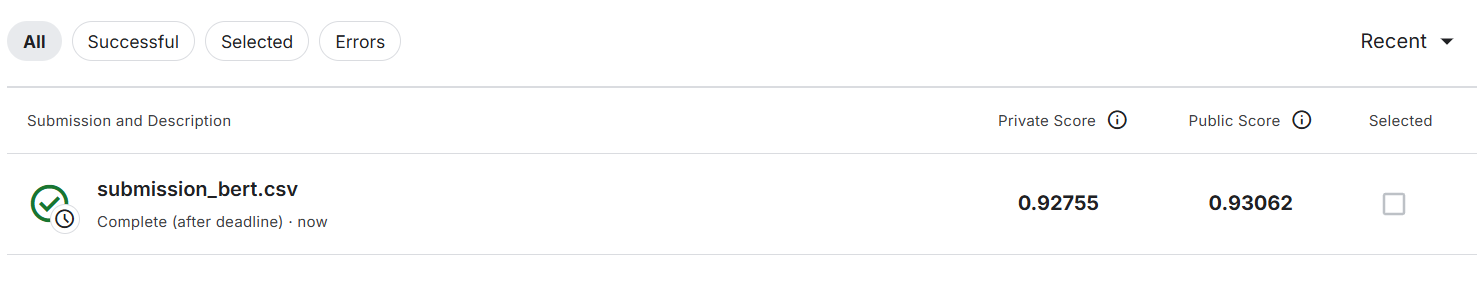

*Kaggle submission — BERT | Public ROC AUC: **0.93062** | Private ROC AUC: **0.92755***

# 4. **Logistic Regression**

Let's read train file once again. 

In [40]:
# Read the training data
df_lr = pd.read_csv('train.csv')
df_lr.head()

,id,comment_text,toxic,severe_toxic,obscene,threat,insult,identity_hate
0,0000997932d777bf,Explanation\nWhy the edits made under my usern...,0,0,0,0,0,0
1,000103f0d9cfb60f,D'aww! He matches this background colour I'm s...,0,0,0,0,0,0
2,000113f07ec002fd,"Hey man, I'm really not trying to edit war. It...",0,0,0,0,0,0
3,0001b41b1c6bb37e,"""\nMore\nI can't make any real suggestions on ...",0,0,0,0,0,0
4,0001d958c54c6e35,"You, sir, are my hero. Any chance you remember...",0,0,0,0,0,0


Let's delete the 'id' column as it is not needed for modeling.

In [41]:
# Remove 'id' column
df_lr = df_lr.drop(columns=['id'], axis=1)
df_lr.head()

,comment_text,toxic,severe_toxic,obscene,threat,insult,identity_hate
0,Explanation\nWhy the edits made under my usern...,0,0,0,0,0,0
1,D'aww! He matches this background colour I'm s...,0,0,0,0,0,0
2,"Hey man, I'm really not trying to edit war. It...",0,0,0,0,0,0
3,"""\nMore\nI can't make any real suggestions on ...",0,0,0,0,0,0
4,"You, sir, are my hero. Any chance you remember...",0,0,0,0,0,0


Split input and output. X is comment texts, y is labels.

In [42]:
# Split input and output
X = df_lr['comment_text']
y = df_lr.drop(columns=['comment_text'], axis=1)

In [43]:
y.head()

,toxic,severe_toxic,obscene,threat,insult,identity_hate
0,0,0,0,0,0,0
1,0,0,0,0,0,0
2,0,0,0,0,0,0
3,0,0,0,0,0,0
4,0,0,0,0,0,0


In [44]:
# Define a function to run and evaluate the pipeline
def run_pipeline(pipeline, X_train, X_test, y_train, y_test):
    # train model
    pipeline.fit(X_train, y_train)
    # predict from model
    predictions = pipeline.predict(X_test)

    if hasattr(pipeline, "predict_proba"):
        pred_probs = pipeline.predict_proba(X_test)
        print('roc_auc:', roc_auc_score(y_test, pred_probs))
        print('roc_auc:', roc_auc_score(y_test, pred_probs))
    # print metrics
    
    print('accuracy:', accuracy_score(y_test, predictions))
    print('classification report')
    print(classification_report(y_test, predictions, target_names=y_train.columns))

We will use TF-IDF vectorizer. TF-IDF stands for Term Frequency – Inverse Document Frequency. It converts text into numeric vectors that capture the importance of words.

* Term Frequency (TF):
    Measures how often a word appears in a document. Frequent words in a document get higher scores.

* Inverse Document Frequency (IDF):
    Measures how rare a word is across all documents. Rare words get higher weight; common words (like “the”, “and”) get lower weight.

* TF-IDF Score:
    Combines TF and IDF to highlight words that are important in a document but not too common in the corpus.

* Result:
    Each document becomes a vector of TF-IDF scores for all words in the vocabulary, which can be used as input for machine learning models.

As well we use `OneVsRestClassifier`. Most classifiers (like Logistic Regression, SVC, Random Forest) are binary by default—they can predict only yes/no for one label. Toxic comment detection has 6 labels: toxic, severe_toxic, obscene, threat, insult, identity_hate. Each comment can belong to multiple labels at once.

OneVsRestClassifier trains one separate binary classifier per label.

In [45]:
# Define pipelines for different classifiers

# Pipeline for Naive Bayes
NB_pipeline = Pipeline([
    ('tfidf', TfidfVectorizer(stop_words='english')),
    ('nb_model', OneVsRestClassifier(MultinomialNB(), n_jobs=-1))
])

# Pipeline for Logistic Regression
LR_pipeline = Pipeline([
    ('tfidf', TfidfVectorizer(stop_words='english')),
    ('nb_model', OneVsRestClassifier(LogisticRegression(), n_jobs=-1))
])

# Pipeline for Support Vector Classifier
SVC_pipeline = Pipeline([
  ('tfidf', TfidfVectorizer(
    stop_words='english'
)),
  ('clf', OneVsRestClassifier(LinearSVC(C=1.5, dual=False), n_jobs=-1))
])

Next task: split data to train and test.

In [46]:
# Split the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

Next let's run each pipeline and compare accuracy.

In [47]:
# Run the Naive Bayes pipeline
run_pipeline(NB_pipeline, X_train, X_test, y_train, y_test)

roc_auc: 0.856408590631694
roc_auc: 0.856408590631694
accuracy: 0.8998276672411092
classification report
               precision    recall  f1-score   support

        toxic       0.99      0.18      0.31      3056
 severe_toxic       0.00      0.00      0.00       321
      obscene       0.98      0.12      0.22      1715
       threat       1.00      0.01      0.03        74
       insult       0.95      0.05      0.10      1614
identity_hate       0.00      0.00      0.00       294

    micro avg       0.98      0.12      0.22      7074
    macro avg       0.65      0.06      0.11      7074
 weighted avg       0.89      0.12      0.21      7074
  samples avg       0.02      0.01      0.01      7074



/home/tetya/toxic_classifier/ml/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in samples with no predicted labels. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/home/tetya/toxic_classifier/ml/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1731: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in samples with no true labels. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/home/tetya/toxic_classifier/ml/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1731: UndefinedMetricWarning: F-score is ill-defined and being set to 0.0 in samples with no true nor predicted labels. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize(

In [48]:
# Run the Logistic Regression pipeline
run_pipeline(LR_pipeline, X_train, X_test, y_train, y_test)

roc_auc: 0.9770330237938792
roc_auc: 0.9770330237938792
accuracy: 0.9179382735390882
classification report
               precision    recall  f1-score   support

        toxic       0.91      0.59      0.72      3056
 severe_toxic       0.55      0.26      0.35       321
      obscene       0.92      0.61      0.74      1715
       threat       0.47      0.09      0.16        74
       insult       0.83      0.50      0.62      1614
identity_hate       0.69      0.15      0.25       294

    micro avg       0.88      0.54      0.67      7074
    macro avg       0.73      0.37      0.47      7074
 weighted avg       0.86      0.54      0.66      7074
  samples avg       0.05      0.05      0.05      7074



/home/tetya/toxic_classifier/ml/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in samples with no predicted labels. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/home/tetya/toxic_classifier/ml/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1731: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in samples with no true labels. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/home/tetya/toxic_classifier/ml/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1731: UndefinedMetricWarning: F-score is ill-defined and being set to 0.0 in samples with no true nor predicted labels. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize(

In [49]:
# Run the Support Vector Classifier pipeline
run_pipeline(SVC_pipeline, X_train, X_test, y_train, y_test)


accuracy: 0.9174369418768604
classification report
               precision    recall  f1-score   support

        toxic       0.86      0.70      0.77      3056
 severe_toxic       0.53      0.33      0.40       321
      obscene       0.88      0.71      0.79      1715
       threat       0.53      0.26      0.35        74
       insult       0.78      0.58      0.66      1614
identity_hate       0.65      0.27      0.38       294

    micro avg       0.83      0.63      0.72      7074
    macro avg       0.70      0.47      0.56      7074
 weighted avg       0.82      0.63      0.71      7074
  samples avg       0.06      0.06      0.06      7074



/home/tetya/toxic_classifier/ml/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in samples with no predicted labels. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/home/tetya/toxic_classifier/ml/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1731: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in samples with no true labels. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/home/tetya/toxic_classifier/ml/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1731: UndefinedMetricWarning: F-score is ill-defined and being set to 0.0 in samples with no true nor predicted labels. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize(

As we can see SVC performs the best among the three classifiers. So we will use it. 

In [50]:
# Load test data
df_test = pd.read_csv('test.csv')

In [51]:
# Run the Support Vector Classifier pipeline
results = SVC_pipeline.predict(df_test['comment_text'])
results

array([[1, 0, 1, 0, 1, 0],
       [0, 0, 0, 0, 0, 0],
       [0, 0, 0, 0, 0, 0],
       ...,
       [0, 0, 0, 0, 0, 0],
       [0, 0, 0, 0, 0, 0],
       [1, 0, 1, 0, 0, 0]], shape=(153164, 6))

In [52]:
# Prepare submission DataFrame
df_final = pd.DataFrame(results,
    columns=["toxic","severe_toxic","obscene","threat","insult","identity_hate"]
)
df_final.insert(0, "id", df_test["id"])

df_final.to_csv("submission_SVC.csv", index=False)

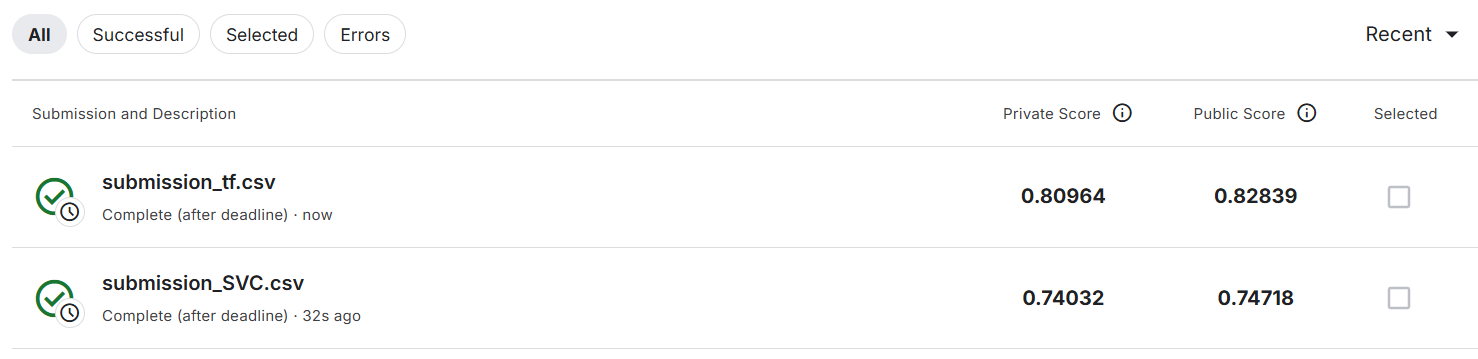

*Kaggle submissions — SVC: Public **0.74718** / Private **0.74032***

Kaggle score (mean column-wise ROC AUC) — SVC Public: **0.74718**

# 5. **TensorFlow Sequential Model**

We use TensorFlow/Keras to build a Sequential model for multi-label toxic comment classification. The architecture:
- **TextVectorization**: converts raw strings to integer token sequences
- **Embedding**: learns dense word representations
- **Bidirectional LSTM**: captures context from both directions
- **Dense + Sigmoid**: outputs a probability for each of the 6 labels independently

In [53]:
import tensorflow as tf
from tensorflow.keras import Sequential
from tensorflow.keras.layers import TextVectorization, Embedding, Bidirectional, LSTM, Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping

print("TensorFlow version:", tf.__version__)
print("GPU available:", tf.config.list_physical_devices('GPU'))

TensorFlow version: 2.20.0
GPU available: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


#### **Data Preparation**

In [54]:
# Load and prepare data
df_tf = pd.read_csv('train.csv')

label_cols = ['toxic', 'severe_toxic', 'obscene', 'threat', 'insult', 'identity_hate']

X_tf = df_tf['comment_text'].values
y_tf = df_tf[label_cols].values.astype('float32')

# Split: 70% train, 15% val, 15% test
X_tf_train, X_tf_temp, y_tf_train, y_tf_temp = train_test_split(X_tf, y_tf, test_size=0.3, random_state=42)
X_tf_val, X_tf_test, y_tf_val, y_tf_test = train_test_split(X_tf_temp, y_tf_temp, test_size=0.5, random_state=42)

print(f"Train: {len(X_tf_train)}, Val: {len(X_tf_val)}, Test: {len(X_tf_test)}")

Train: 111699, Val: 23936, Test: 23936


In [55]:
# Build TextVectorization layer and adapt it on training texts only
MAX_TOKENS = 20000
SEQUENCE_LEN = 200

vectorizer = TextVectorization(
    max_tokens=MAX_TOKENS,
    output_sequence_length=SEQUENCE_LEN,
    output_mode='int'
)
vectorizer.adapt(X_tf_train)

print(f"Vocabulary size: {len(vectorizer.get_vocabulary())}")

I0000 00:00:1776711662.703824    1192 gpu_device.cc:2020] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 1186 MB memory:  -> device: 0, name: NVIDIA GeForce RTX 3060 Laptop GPU, pci bus id: 0000:01:00.0, compute capability: 8.6


Vocabulary size: 20000


In [56]:
# Create tf.data pipelines for efficient batching
BATCH_SIZE = 64

def make_dataset(texts, labels, shuffle=False):
    ds = tf.data.Dataset.from_tensor_slices((texts, labels))
    if shuffle:
        ds = ds.shuffle(buffer_size=10000)
    return ds.batch(BATCH_SIZE).prefetch(tf.data.AUTOTUNE)

train_ds = make_dataset(X_tf_train, y_tf_train, shuffle=True)
val_ds   = make_dataset(X_tf_val,   y_tf_val)
test_ds  = make_dataset(X_tf_test,  y_tf_test)

#### **Model Building**

In [57]:
model_tf = Sequential([
    vectorizer,
    Embedding(input_dim=MAX_TOKENS, output_dim=128, mask_zero=True),
    Bidirectional(LSTM(64, return_sequences=False)),
    Dropout(0.3),
    Dense(64, activation='relu'),
    Dropout(0.3),
    Dense(6, activation='sigmoid')   # sigmoid for independent multi-label probabilities
])

model_tf.compile(
    optimizer='adam',
    loss='binary_crossentropy',   # independent binary loss per label
    metrics=['accuracy', tf.keras.metrics.AUC(name='auc', multi_label=True)]
)

model_tf.summary()

#### **Handling Class Imbalance**

Since most comments are non-toxic, we compute per-label class weights so rare labels like `threat` and `identity_hate` receive proportionally higher loss contribution during training.

In [58]:
# Compute sample weights: each sample's weight = max pos_weight across its active labels
label_pos_counts = y_tf_train.sum(axis=0)
total_train = len(y_tf_train)
pos_weights_tf = (total_train - label_pos_counts) / (label_pos_counts + 1e-6)

print("Per-label positive weights:", dict(zip(label_cols, pos_weights_tf.round(2))))

# Assign each sample the highest weight among its active labels (1.0 for clean comments)
sample_weights = np.where(
    y_tf_train.sum(axis=1, keepdims=True) > 0,
    (y_tf_train * pos_weights_tf).max(axis=1, keepdims=True),
    1.0
).squeeze()

print(f"Sample weight range: {sample_weights.min():.1f} – {sample_weights.max():.1f}")

Per-label positive weights: {'toxic': np.float32(9.43), 'severe_toxic': np.float32(99.72), 'obscene': np.float32(17.95), 'threat': np.float32(325.61), 'insult': np.float32(19.35), 'identity_hate': np.float32(113.8)}
Sample weight range: 1.0 – 325.6


In [59]:
# Rebuild train dataset with sample weights
train_ds_weighted = (
    tf.data.Dataset.from_tensor_slices((X_tf_train, y_tf_train, sample_weights))
    .shuffle(10000)
    .batch(BATCH_SIZE)
    .prefetch(tf.data.AUTOTUNE)
)

#### **Model Training**

In [60]:
early_stop = EarlyStopping(monitor='val_auc', patience=2, restore_best_weights=True, mode='max')

history = model_tf.fit(
    train_ds_weighted,
    validation_data=val_ds,
    epochs=10,
    callbacks=[early_stop]
)

Epoch 1/10


2026-04-20 21:01:48.652589: I external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:473] Loaded cuDNN version 91002


1746/1746 ━━━━━━━━━━━━━━━━━━━━ 93s 50ms/step - accuracy: 0.8177 - auc: 0.9062 - loss: 2.0384 - val_accuracy: 0.9791 - val_auc: 0.9657 - val_loss: 0.1199
Epoch 2/10
1746/1746 ━━━━━━━━━━━━━━━━━━━━ 88s 51ms/step - accuracy: 0.8500 - auc: 0.9692 - loss: 1.5223 - val_accuracy: 0.9739 - val_auc: 0.9643 - val_loss: 0.0791
Epoch 3/10
1746/1746 ━━━━━━━━━━━━━━━━━━━━ 82s 47ms/step - accuracy: 0.8047 - auc: 0.9799 - loss: 1.2819 - val_accuracy: 0.9653 - val_auc: 0.9645 - val_loss: 0.1440


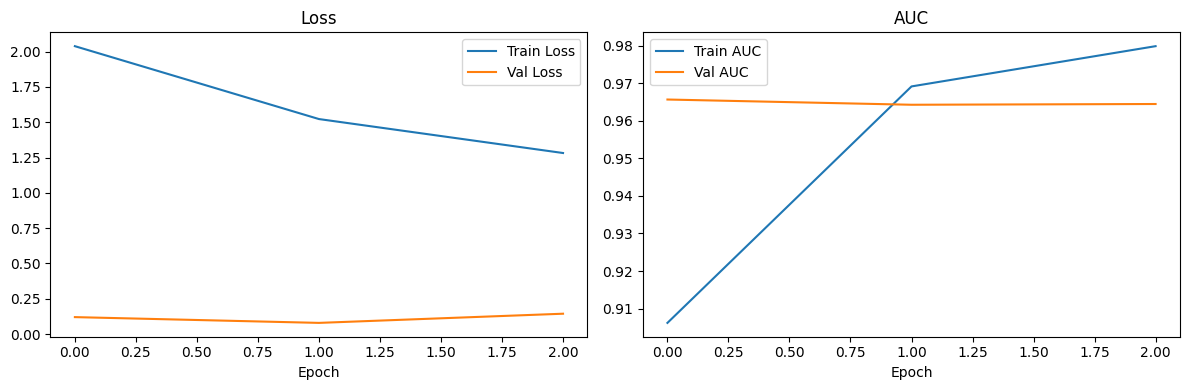

In [61]:
# Plot training history
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].plot(history.history['loss'], label='Train Loss')
axes[0].plot(history.history['val_loss'], label='Val Loss')
axes[0].set_title('Loss')
axes[0].set_xlabel('Epoch')
axes[0].legend()

axes[1].plot(history.history['auc'], label='Train AUC')
axes[1].plot(history.history['val_auc'], label='Val AUC')
axes[1].set_title('AUC')
axes[1].set_xlabel('Epoch')
axes[1].legend()

plt.tight_layout()
plt.show()

#### **Model Evaluation**

In [62]:
# Get predictions on test set
preds_tf = model_tf.predict(test_ds)
binary_preds_tf = (preds_tf > 0.5).astype(int)

# Per-label metrics
for i, label in enumerate(label_cols):
    f1  = f1_score(y_tf_test[:, i], binary_preds_tf[:, i])
    prec = precision_score(y_tf_test[:, i], binary_preds_tf[:, i], zero_division=0)
    rec  = recall_score(y_tf_test[:, i], binary_preds_tf[:, i], zero_division=0)
    print(f"{label:<15} F1: {f1:.4f}  Precision: {prec:.4f}  Recall: {rec:.4f}")

print()
# Overall micro-averaged metrics
print("Overall (micro-averaged):")
print(f"  F1:        {f1_score(y_tf_test, binary_preds_tf, average='micro'):.4f}")
print(f"  Precision: {precision_score(y_tf_test, binary_preds_tf, average='micro', zero_division=0):.4f}")
print(f"  Recall:    {recall_score(y_tf_test, binary_preds_tf, average='micro', zero_division=0):.4f}")
print(f"  ROC-AUC:   {roc_auc_score(y_tf_test, preds_tf, average='micro'):.4f}")

374/374 ━━━━━━━━━━━━━━━━━━━━ 7s 17ms/step
toxic           F1: 0.6023  Precision: 0.4589  Recall: 0.8759
severe_toxic    F1: 0.4908  Precision: 0.4183  Recall: 0.5935
obscene         F1: 0.7820  Precision: 0.7990  Recall: 0.7657
threat          F1: 0.1429  Precision: 0.0795  Recall: 0.7015
insult          F1: 0.6854  Precision: 0.6227  Recall: 0.7621
identity_hate   F1: 0.2857  Precision: 0.3630  Recall: 0.2356

Overall (micro-averaged):
  F1:        0.6165
  Precision: 0.5090
  Recall:    0.7816
  ROC-AUC:   0.9721


#### **Generate Test Predictions**

In [63]:
# Load test data and generate submission
df_test_tf = pd.read_csv('test.csv')
test_comments = df_test_tf['comment_text'].fillna(' ').replace('', ' ').values

# Run eagerly to bypass cuDNN masked-LSTM restriction during inference
tf.config.run_functions_eagerly(True)

test_probs_tf = model_tf.predict(
    tf.data.Dataset.from_tensor_slices(test_comments)
    .batch(BATCH_SIZE)
    .prefetch(tf.data.AUTOTUNE)
)

tf.config.run_functions_eagerly(False)

test_preds_tf = (test_probs_tf > 0.5).astype(int)

df_submission_tf = pd.DataFrame(test_preds_tf, columns=label_cols)
df_submission_tf.insert(0, 'id', df_test_tf['id'])
df_submission_tf.to_csv('submission_tf.csv', index=False)

print("Saved submission_tf.csv")
df_submission_tf.head()

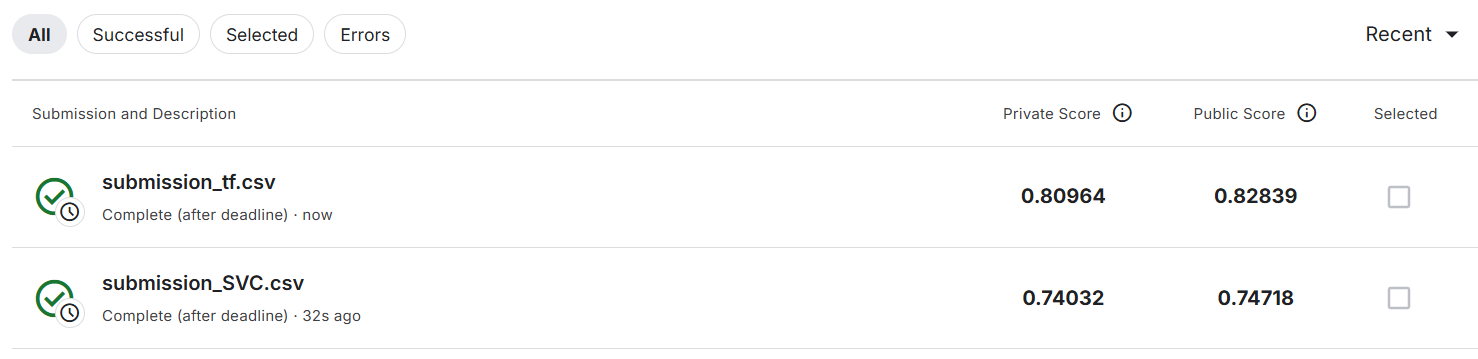

*Kaggle submissions — TF BiLSTM: Public **0.82839** / Private **0.80964** 

# 6. **Project Summary**

## Dataset

| Property | Value |
|----------|-------|
| Total comments | 159,571 |
| Labels | 6 (toxic, severe_toxic, obscene, threat, insult, identity_hate) |
| Missing values | None |
| Duplicate entries | None |
| Class balance | Heavily imbalanced — only ~9.6% toxic |

**Label distribution:**

| Label | Count | % of total |
|-------|-------|------------|
| toxic | 15,294 | 9.58% |
| obscene | 8,449 | 5.29% |
| insult | 7,877 | 4.94% |
| severe_toxic | 1,595 | 1.00% |
| identity_hate | 1,405 | 0.88% |
| threat | 478 | 0.30% |

---

## Kaggle Results (Mean Column-Wise ROC AUC)

| Model | Public Score | Private Score |
|-------|:-----------:|:-------------:|
| 🥇 **BERT** (PyTorch) | **0.93062** | **0.92755** |
| 🥈 **BiLSTM** (TensorFlow) | **0.82839** | **0.80964** |
| 🥉 **LinearSVC** (scikit-learn) | **0.74718** | **0.74032** |

---

## Model 1: PyTorch + BERT

**Setup:**
- Architecture: `bert-base-uncased` + 6-label classification head
- Max sequence length: 128 tokens
- Loss: `BCEWithLogitsLoss` with per-label positive weights
- Optimizer: AdamW, lr=2e-5, batch size=8
- Split: 70% train (111,699) / 20% val (33,510) / 10% test (14,362)

**Training (5 epochs, completed):**

| Epoch | Loss |
|-------|------|
| 1 | 0.3553 |
| 2 | 0.2582 |
| 3 | 0.2142 |
| 4 | 0.1855 |
| 5 | 0.1769 |

**Validation results (threshold = 0.5):**

| Label | F1 | Precision | Recall |
|-------|----|-----------|--------|
| toxic | 0.699 | 0.562 | 0.926 |
| severe_toxic | 0.277 | 0.161 | 0.988 |
| obscene | 0.742 | 0.609 | 0.948 |
| threat | 0.298 | 0.182 | 0.826 |
| insult | 0.671 | 0.522 | 0.938 |
| identity_hate | 0.209 | 0.118 | 0.898 |
| **micro avg** | **0.595** | **0.436** | **0.934** |

- **Kaggle: Public ROC AUC 0.93062 | Private 0.92755** ← best model

---

## Model 2: LinearSVC (scikit-learn)

**Setup:**
- Pipeline: `TfidfVectorizer(stop_words=english)` → `OneVsRestClassifier(LinearSVC)`
- Split: 80% train / 20% test
- Three classifiers compared: Naive Bayes, Logistic Regression, LinearSVC

**Classifier comparison:**

| Classifier | Accuracy | ROC-AUC | Micro F1 |
|------------|----------|---------|----------|
| Naive Bayes | 89.98% | 0.856 | 0.22 |
| Logistic Regression | 91.79% | 0.977 | 0.67 |
| **LinearSVC** *(chosen)* | **91.74%** | — | **0.72** |

**LinearSVC test results:**

| Label | F1 | Precision | Recall |
|-------|----|-----------|--------|
| toxic | 0.77 | 0.86 | 0.70 |
| severe_toxic | 0.40 | 0.53 | 0.33 |
| obscene | 0.79 | 0.88 | 0.71 |
| threat | 0.35 | 0.53 | 0.26 |
| insult | 0.66 | 0.78 | 0.58 |
| identity_hate | 0.38 | 0.65 | 0.27 |
| **micro avg** | **0.72** | **0.83** | **0.63** |

- **Kaggle: Public ROC AUC 0.74718 | Private 0.74032**

---

## Model 3: TensorFlow BiLSTM

**Setup:**
- Architecture: `TextVectorization(20k vocab)` → `Embedding(128d)` → `Bidirectional LSTM(64)` → `Dropout(0.3)` → `Dense(64, relu)` → `Dense(6, sigmoid)`
- Max sequence length: 200 tokens
- Loss: `binary_crossentropy` with per-sample class weights (range: 1.0–325.6)
- Optimizer: Adam, batch size=64
- Split: 70% train (111,699) / 15% val (23,936) / 15% test (23,936)
- Early stopping: patience=2 on `val_auc`
- GPU: NVIDIA GeForce RTX 3060 Laptop (1,186 MB)

**Training (3 epochs, early stopped):**

| Epoch | Train AUC | Val AUC | Train Loss | Val Loss |
|-------|-----------|---------|------------|----------|
| 1 | 0.906 | 0.966 | 2.038 | 0.120 |
| 2 | 0.969 | 0.964 | 1.522 | 0.079 |
| 3 | 0.980 | 0.965 | 1.282 | 0.144 |

**Test results (threshold = 0.5):**

| Label | F1 | Precision | Recall |
|-------|----|-----------|--------|
| toxic | 0.602 | 0.459 | 0.876 |
| severe_toxic | 0.491 | 0.418 | 0.594 |
| obscene | 0.782 | 0.799 | 0.766 |
| threat | 0.143 | 0.080 | 0.702 |
| insult | 0.685 | 0.623 | 0.762 |
| identity_hate | 0.286 | 0.363 | 0.236 |
| **micro avg** | **0.617** | **0.509** | **0.782** |
| **val ROC-AUC** | **0.972** | — | — |

- **Kaggle: Public ROC AUC 0.82839 | Private 0.80964**

---

## Key Findings

1. **BERT achieved the best Kaggle score (public ROC AUC 0.931)** — deep contextual understanding of language gives it a strong advantage despite slower training
2. **TF BiLSTM ranked second (0.828)** — a good result for a much simpler model trained in ~4 minutes per epoch
3. **LinearSVC ranked third (0.747)** — despite being the fastest to train, TF-IDF lacks the semantic depth of neural models
4. **`threat` and `identity_hate`** are the hardest labels across all models — fewest samples (478 and 1,405) and lowest F1 in every approach
5. **Class imbalance** is the central challenge — all models used weighting strategies, yet rare labels remain difficult
6. **Precision vs Recall tradeoff**: BERT and BiLSTM favoured recall (catch everything), LinearSVC had the best precision/recall balance
